# Домашнее Задание

In [156]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

## Logistic Regression (Своими Силами)

1. Дописать код градиентного спуска ниже
2. Поиграться с датасетом, предложеннным выше
3. Построить свою версию Логистической регресии (на каком-то одном числовом факторе без пропусков), сравнить результаты с LogisticRegression из SKlearn (Оценить метрики - ROC AUC, подобрать порог и Построить Confusion Matrix, а так же производные метрики от неё )
4. Заполнить пропуски, обработать категориальные переменные, обучить свою версию модели и Logistic Regression, сравнить качество между ними (см п.3) + с моделями из п.3 (как добавление бОльшего количества факторов влияет на качество модели)
5. *Поиграться с нормировкой данных (sklearn.model_selection.StandardScaler) оценить эффект на веса модели и её качество
6. Разбить факторы на Клиентские/Продуктовые/Кредитная История и построить по одной модели на каждом факторе. Затем построить мета-модель (интегральная модель) на трёх факторах - скорах метамоделях (дрейверы) - Сравнить результаты по каждому из драйеров + интегральной модели с одной моделью на всём факторном прстранстве.
7. *Привести график качества (ROC AUC) модели на фиксированной тренировочной выборке в зависимости от количества наблюдений, которые используются при обучении (train выборка). Например: 100, 500, 1000 и тд.

*- задания со звёздочкой, не обязательно, но довольно интересные

## Plot funcs

In [157]:
def plot_roc_auc(y_true, y_proba, model_name="Model"):
    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


In [158]:
def plot_confusion_matrix(y_true, y_proba, thresholds=0.5, label=None):
    import matplotlib.pyplot as plt
    import seaborn as sns

    if isinstance(thresholds, (float, int)):
        thresholds = [thresholds]

    n = len(thresholds)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

    if n == 1:
        axes = [axes]  # Приводим к списку

    for i, threshold in enumerate(thresholds):
        y_pred = (y_proba >= threshold).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        # Текстовая информация
        print(f"\n=== Threshold: {threshold:.2f} ===")
        print("Confusion Matrix:")
        print(cm)
        print(f"Accuracy:  {acc:.3f}")
        print(f"Precision: {prec:.3f}")
        print(f"Recall:    {rec:.3f}")
        print(f"F1 Score:  {f1:.3f}")

        # Отрисовка матрицы в своей оси
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Predicted Negative", "Predicted Positive"],
                    yticklabels=["Actual Negative", "Actual Positive"],
                    ax=axes[i])

        title = f"{label + ' ' if label else ''}Threshold = {threshold:.2f}"
        axes[i].set_title(title)
        axes[i].set_ylabel("True label")
        axes[i].set_xlabel("Predicted label")

    plt.tight_layout()
    plt.show()


In [159]:
def plot_metrics(y_true, y_proba):
    thresholds = np.linspace(0, 1, 200)
    precisions, recalls, f1s = [], [], []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred))
        f1s.append(f1_score(y_true, y_pred))

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precisions, label="Precision", color='blue')
    plt.plot(thresholds, recalls, label="Recall", color='green')
    plt.plot(thresholds, f1s, label="F1 Score", color='red')
    
    # Максимумы
    best_f1_idx = np.argmax(f1s)
    print(f"Optimal threshold for F1 Score: {thresholds[best_f1_idx]:.2f}")
    plt.axvline(thresholds[best_f1_idx], linestyle='--', color='gray', label=f'Best F1 = {thresholds[best_f1_idx]:.2f}')

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision, Recall & F1 Score vs Threshold")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## My LogRegression

In [88]:
def sigmoid(z):
  return 1.0/(1.0+np.exp(-z))

def logloss(y, p):
    return -(y*np.log(p + 1e-15) + (1-y)*np.log(1-p + 1e-15)).mean()

In [160]:
# Реализуем собственный класс логистической регрессии
class MyLogisticRegression:
    def __init__(self, lr=1e-4, bias=True):
      self.bias = bool(bias)
      self.weights = None
      self.lr = lr

    def preproc_x(self, X):
      # Добавляем bias если требуется
      return np.hstack([np.ones((X.shape[0], 1)), X]) if self.bias else X

    def fit(self, X, y, c_epoch=1000):
      # Инициализируем веса
      self.weights = np.ones(X.shape[1]+self.bias)

      self.X = self.preproc_x(X)
      self.y = y


      # Стохастический градиентный спуск
      # Итерируемся по количеству эпох
      for i in range(c_epoch):
        # Перешмешиваем наблюдения случайным образом
        ids = list(range(self.X.shape[0]))
        np.random.shuffle(ids)

        # итерируемся по наблюдениям
        for j in ids:
          p = sigmoid(np.dot(self.X[j], self.weights))
          grad = (p - self.y[j]) * self.X[j]
          self.weights -= self.lr * grad
          # self.weights += self.lr * (self.y[j] - p) * self.X[j]
        
        p = sigmoid(self.X @ self.weights)

        if i % 50 == 0:
          print(i , 'logloss:', logloss(self.y, p))

    def predict_proba(self, X):
      X = self.preproc_x(X)
      return sigmoid((X @ self.weights)*1)

    def predict(self, X):
      X = self.preproc_x(X)
      preds = (sigmoid((X @ self.weights)*1) > 0.5).astype(int)
      preds[preds == 0] = -1
      return preds

## Dataset

Made changes.

Made changes.

Класс теперь полностью реализован: в методе обучения добавлен расчет производной функции потерь по весам для стохастического градиентного спуска. Можно использовать этот класс для обучения и сравнения с реализацией из sklearn. Если нужно — покажу пример использования или помогу с тестированием.

In [161]:
# Считываем скачанный csv файл
df = pd.read_csv('loan_data.csv')

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [163]:
from numpy import random
# зашумим часть данных для дальнейшего интереса :-)

# Зашумим случаный 1000 возрастов (может быть меньше с учетом коллизий индексов)
# Это даст нам случайное распределение пустот
df.loc[random.choice(range(df.shape[0]), 1000), 'person_age'] = np.nan

# Уберём значительную часть доходов у людей, которые хотят взять кредит на образование
# Это зашумление нам даст неслучайное смещение
df.loc[df[df['loan_intent'] == 'EDUCATION'].sample(3000).index, 'person_income'] = np.nan

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44010 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   42000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## Строим Логрегрессисю на 1 числовой фиче

In [165]:
# Заведём константу, чтобы каждый раз не вспоминать как называется колонка с таргетом
TARGET = 'loan_status'


In [166]:
# Разбить на train и test выборки
train, test = train_test_split(df, test_size=0.25, random_state=43)

In [172]:
# Построить свою версию Логистической регресии (на каком-то одном числовом факторе без пропусков)
features = ['loan_int_rate']

In [173]:
X_train = train[features]
y_train = train[TARGET].values

X_test = test[features]
y_test = test[TARGET].values

In [174]:
# Обучить свою версию и sklearn'овскую версию Логистической Регрессии

my_lr = MyLogisticRegression()
sk_lr = LogisticRegression()

my_lr.fit(X_train, y_train)
sk_lr.fit(X_train, y_train)

0 logloss: 0.6203318110033514
50 logloss: 0.4786444486624351
100 logloss: 0.4742145488357125
150 logloss: 0.47488459072076117
200 logloss: 0.4750503856402943
250 logloss: 0.4749051124318732
300 logloss: 0.47515306360970094
350 logloss: 0.47590951760413186
400 logloss: 0.4738661454247359
450 logloss: 0.4757167669377024
500 logloss: 0.47390677911387075
550 logloss: 0.475914419345278
600 logloss: 0.47439483242539066
650 logloss: 0.47529080443157284
700 logloss: 0.4740345232508554
750 logloss: 0.47389936336434596
800 logloss: 0.4743810336143375
850 logloss: 0.4738710557929222
900 logloss: 0.4738920685420827
950 logloss: 0.4738591335419751


LogisticRegression()

=============== MyLogReg ===============


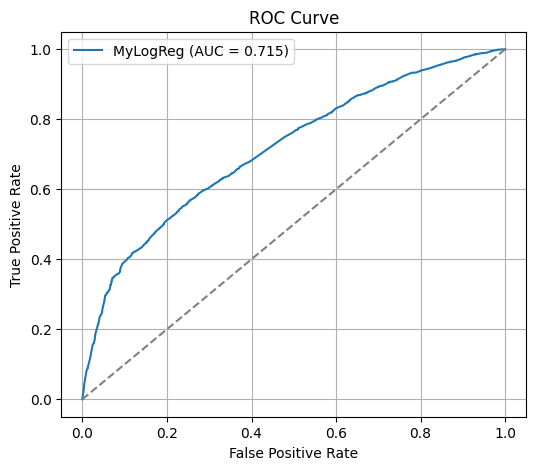

Optimal threshold for F1 Score: 0.29


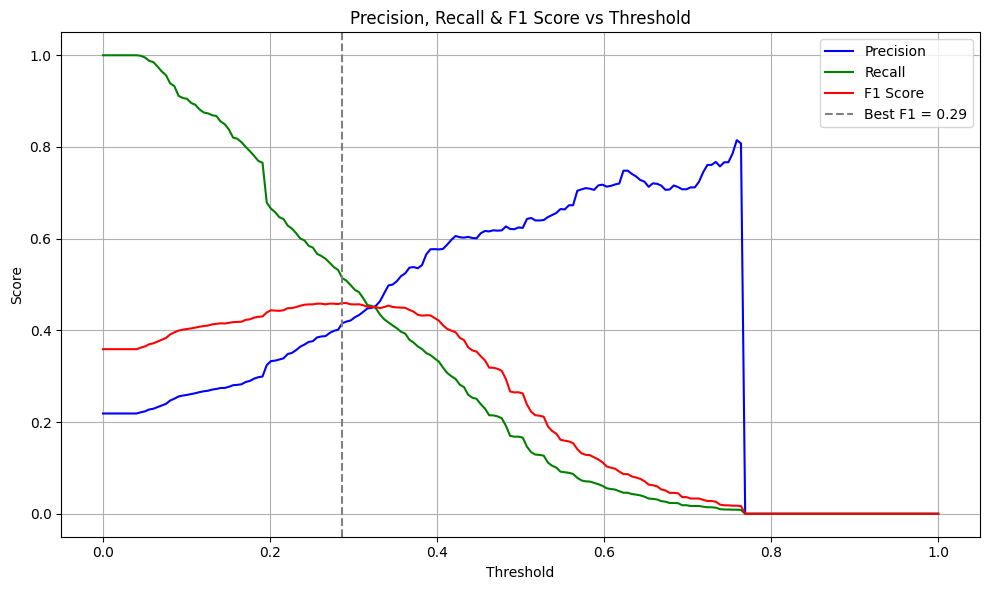

------------------------------------------------------------
=============== SklearnLogReg ===============


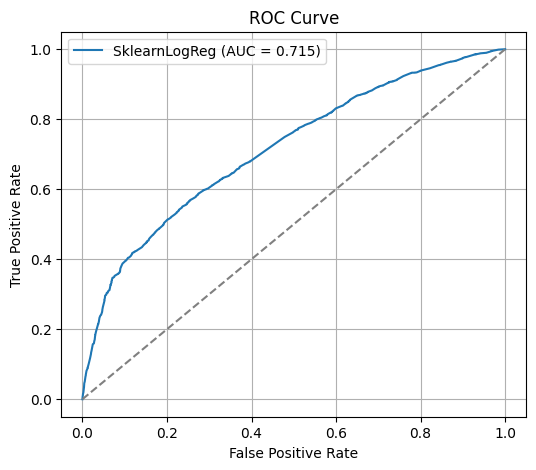

Optimal threshold for F1 Score: 0.29


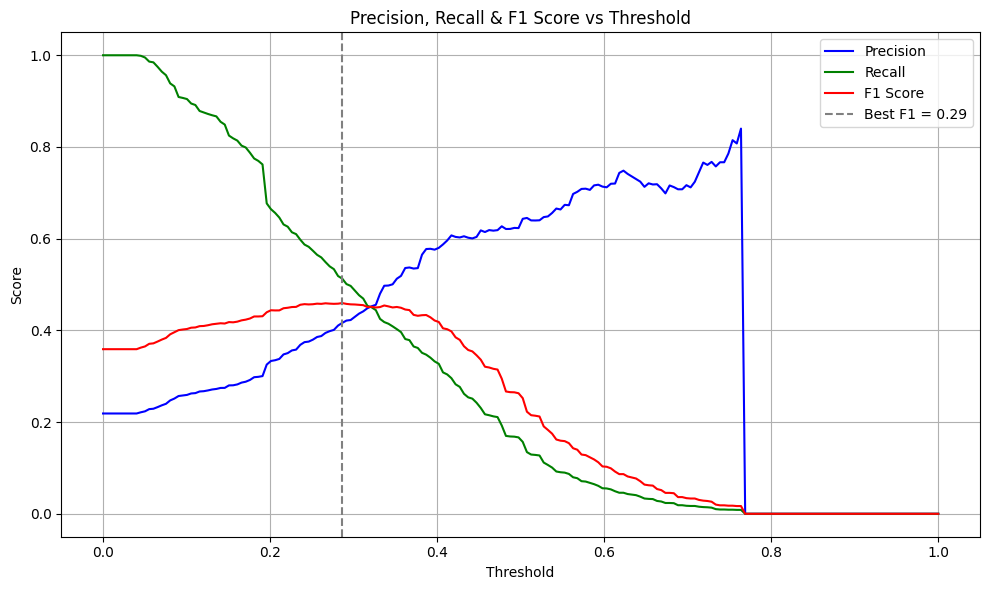

In [175]:
my_proba = my_lr.predict_proba(X_test)
sk_proba = sk_lr.predict_proba(X_test)[:, 1]

print("=============== MyLogReg ===============")
plot_roc_auc(y_test, my_proba, model_name="MyLogReg")
plot_metrics(y_test, my_proba)

print('---' * 20)
print("=============== SklearnLogReg ===============")
plot_roc_auc(y_test, sk_proba, model_name="SklearnLogReg")
plot_metrics(y_test, sk_proba)


=== Threshold: 0.29 ===
Confusion Matrix:
[[7023 1766]
 [1199 1262]]
Accuracy:  0.736
Precision: 0.417
Recall:    0.513
F1 Score:  0.460

=== Threshold: 0.50 ===
Confusion Matrix:
[[8541  248]
 [2050  411]]
Accuracy:  0.796
Precision: 0.624
Recall:    0.167
F1 Score:  0.263


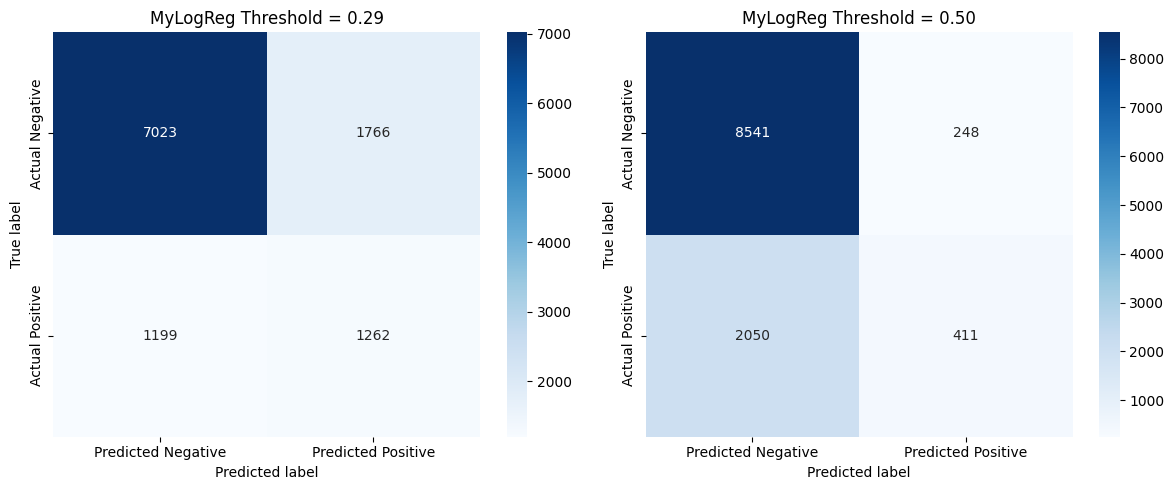


=== Threshold: 0.29 ===
Confusion Matrix:
[[7061 1728]
 [1212 1249]]
Accuracy:  0.739
Precision: 0.420
Recall:    0.508
F1 Score:  0.459

=== Threshold: 0.50 ===
Confusion Matrix:
[[8545  244]
 [2055  406]]
Accuracy:  0.796
Precision: 0.625
Recall:    0.165
F1 Score:  0.261


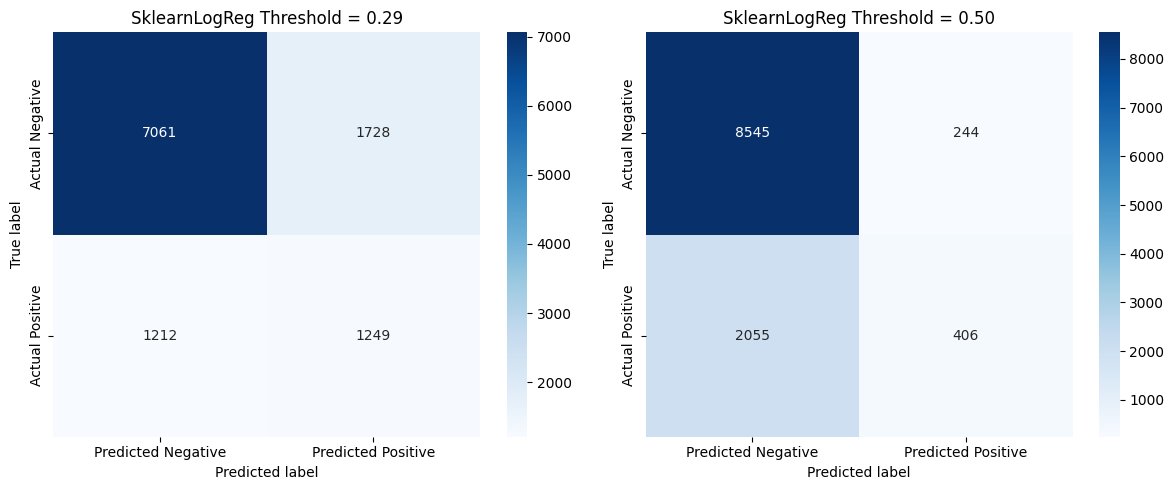

In [176]:
thresholds = [0.29, 0.5]

plot_confusion_matrix(y_test, my_proba, thresholds=thresholds, label='MyLogReg')

plot_confusion_matrix(y_test, sk_proba, thresholds=thresholds, label='SklearnLogReg')

## Логрегрессия на всех фичах

### Разделение фичей

In [ ]:
# Убрали коррелирование фичи
numeric_features = train.drop([TARGET,'person_emp_exp','cb_person_cred_hist_length'], axis=1).select_dtypes(include=['int64', 'float64']).columns
categorical_features = train.drop(TARGET, axis=1).select_dtypes(include=['object', 'category']).columns

In [192]:
X_train = train.drop(TARGET, axis=1)
y_train = train[TARGET].values

X_test = test.drop(TARGET, axis=1)
y_test = test[TARGET].values

### Пайплайн для обработки

In [193]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [194]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### Корреляция фичей


Top 10 most correlated feature pairs:
previous_loan_defaults_on_file_No  previous_loan_defaults_on_file_Yes    1.000000
person_gender_female               person_gender_male                    1.000000
person_home_ownership_MORTGAGE     person_home_ownership_RENT            0.871250
loan_amnt                          loan_percent_income                   0.594032
person_education_Associate         person_education_Bachelor             0.395573
person_education_Bachelor          person_education_High School          0.391255
person_education_Associate         person_education_High School          0.364205
person_education_Bachelor          person_education_Master               0.278176
person_home_ownership_OWN          person_home_ownership_RENT            0.277096
person_education_Associate         person_education_Master               0.258944
dtype: float64


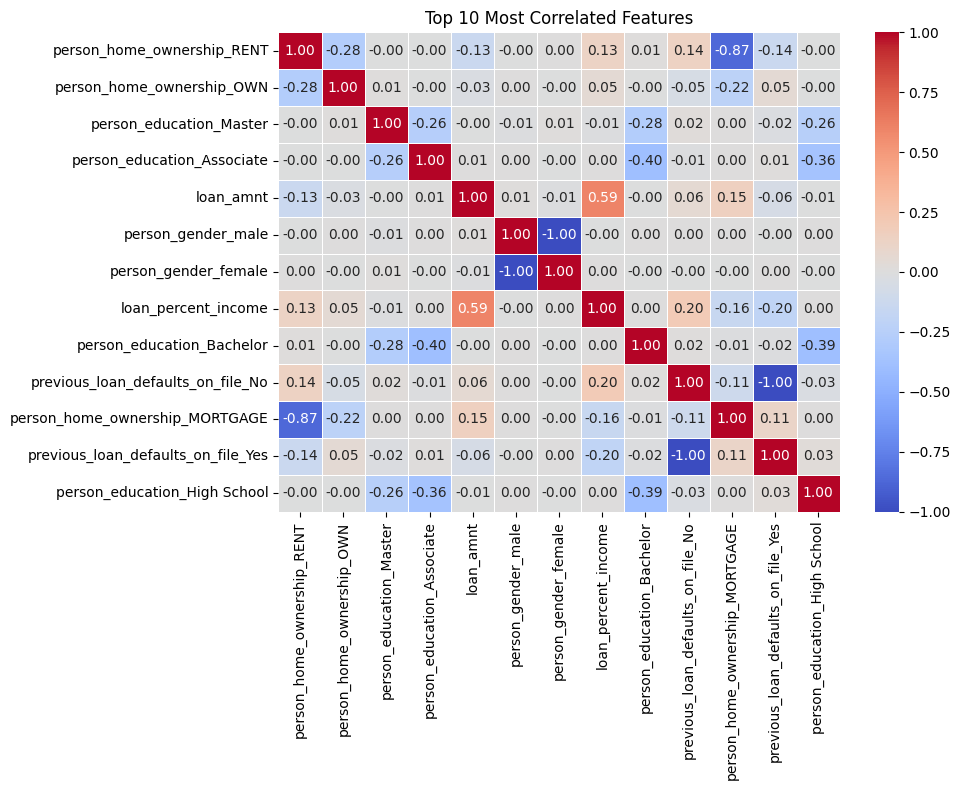

In [195]:
# Получение имен признаков после трансформации
def get_feature_names(column_transformer):
    output_features = []

    for name, trans, cols in column_transformer.transformers_:
        if name != 'remainder':
            if hasattr(trans, 'get_feature_names_out'):
                names = trans.get_feature_names_out(cols)
            else:
                names = cols
            output_features.extend(names)

    return output_features

# Преобразуем X_train_processed в DataFrame
feature_names = get_feature_names(preprocessor)
X_train_df = pd.DataFrame(X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,
                          columns=feature_names)

# Оставим только числовые признаки
numeric_df = X_train_df.select_dtypes(include=[np.number])

# Построение полной корреляционной матрицы
corr_matrix = numeric_df.corr()

# Оставим только верхний треугольник без диагонали
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_triangle = corr_matrix.where(mask)

# Найдём топ-10 по модулю корреляции
top_pairs = (upper_triangle
             .stack()
             .abs()
             .sort_values(ascending=False)
             .head(10))

print("\nTop 10 most correlated feature pairs:")
print(top_pairs)

# Визуализация только этих признаков
top_features = list(set([feat for pair in top_pairs.index for feat in pair]))
top_corr = numeric_df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Top 10 Most Correlated Features")
plt.tight_layout()
plt.show()


## Построение модели

### Обучаем модель

In [196]:
# Обучить свою версию и sklearn'овскую версию Логистической Регрессии

my_lr = MyLogisticRegression()
sk_lr = LogisticRegression()

my_lr.fit(X_train_processed, y_train)
sk_lr.fit(X_train_processed, y_train)

0 logloss: 1.0304129779258053
50 logloss: 0.2302491962436177
100 logloss: 0.22612525341243736
150 logloss: 0.22490487770718168
200 logloss: 0.22437523872375675
250 logloss: 0.22409035553818624
300 logloss: 0.22391460307115685
350 logloss: 0.22379698733180672
400 logloss: 0.22371078810368572
450 logloss: 0.22364452773091795
500 logloss: 0.2235936077655046
550 logloss: 0.22355256161878506
600 logloss: 0.22352019688952712
650 logloss: 0.22349139307690258
700 logloss: 0.22346725249488836
750 logloss: 0.22344741431401752
800 logloss: 0.22342941630586563
850 logloss: 0.2234137086436165
900 logloss: 0.2234003222710835
950 logloss: 0.2233876363269743


LogisticRegression()

### Метрики

=============== MyLogReg ===============


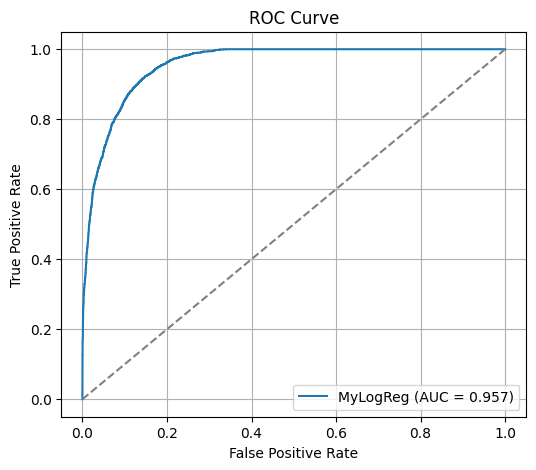

Optimal threshold for F1 Score: 0.44


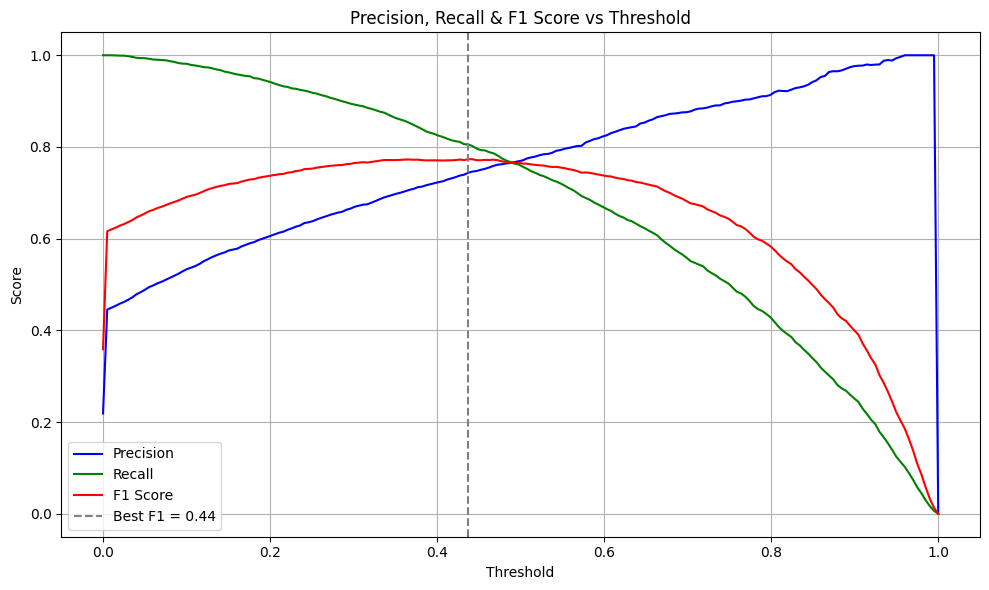

------------------------------------------------------------
=============== SklearnLogReg ===============


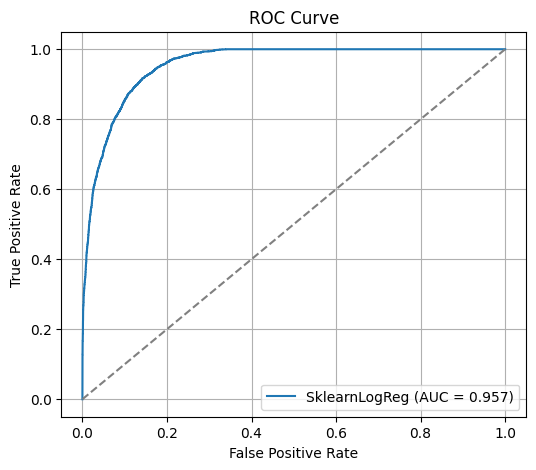

Optimal threshold for F1 Score: 0.44


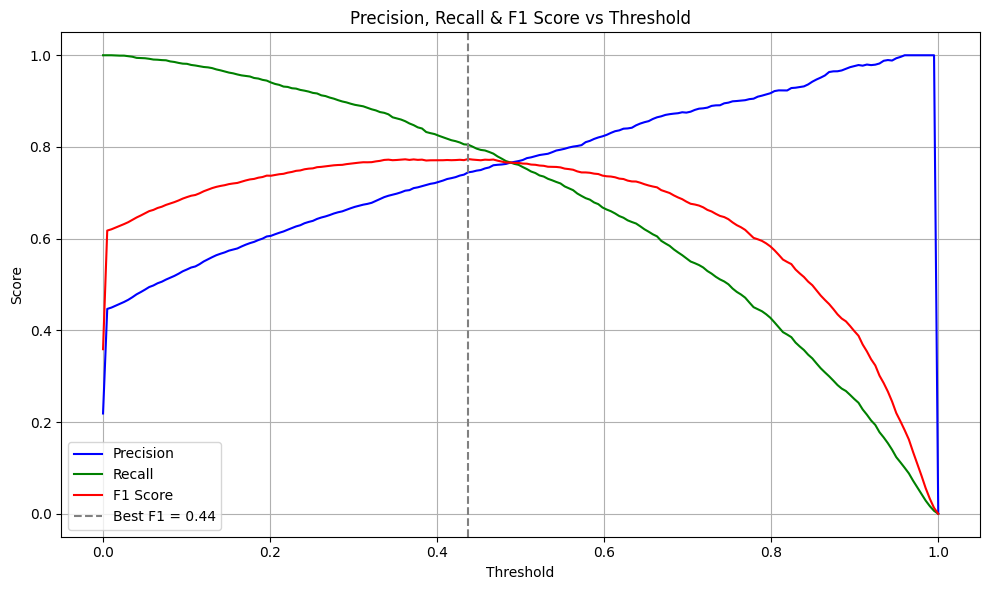

In [198]:
my_proba = my_lr.predict_proba(X_test_processed)
sk_proba = sk_lr.predict_proba(X_test_processed)[:, 1]

print("=============== MyLogReg ===============")
plot_roc_auc(y_test, my_proba, model_name="MyLogReg")
plot_metrics(y_test, my_proba)

print('---' * 20)
print("=============== SklearnLogReg ===============")
plot_roc_auc(y_test, sk_proba, model_name="SklearnLogReg")
plot_metrics(y_test, sk_proba)


=== Threshold: 0.39 ===
Confusion Matrix:
[[7984  805]
 [ 415 2046]]
Accuracy:  0.892
Precision: 0.718
Recall:    0.831
F1 Score:  0.770

=== Threshold: 0.44 ===
Confusion Matrix:
[[8111  678]
 [ 486 1975]]
Accuracy:  0.897
Precision: 0.744
Recall:    0.803
F1 Score:  0.772


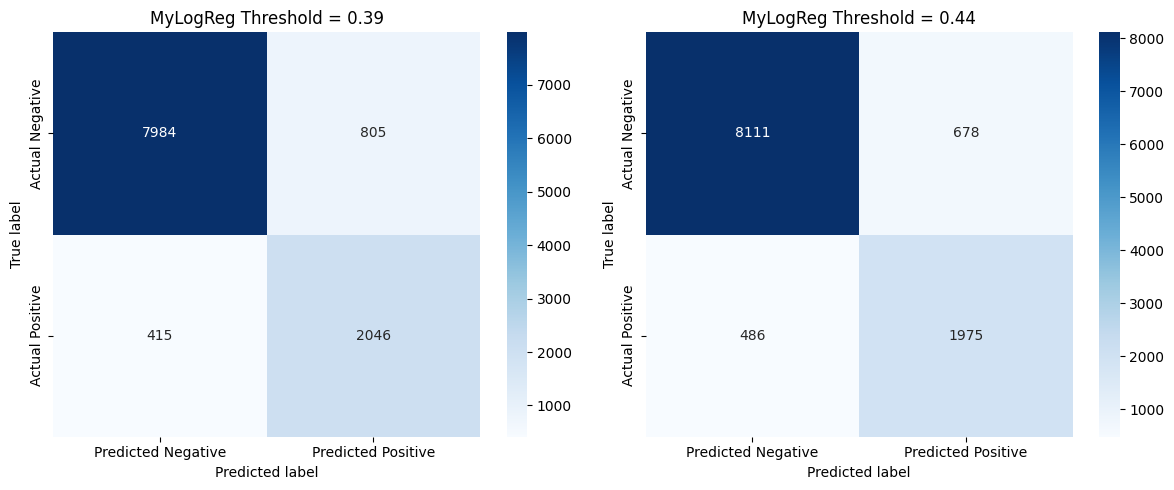


=== Threshold: 0.39 ===
Confusion Matrix:
[[7987  802]
 [ 414 2047]]
Accuracy:  0.892
Precision: 0.718
Recall:    0.832
F1 Score:  0.771

=== Threshold: 0.44 ===
Confusion Matrix:
[[8115  674]
 [ 486 1975]]
Accuracy:  0.897
Precision: 0.746
Recall:    0.803
F1 Score:  0.773


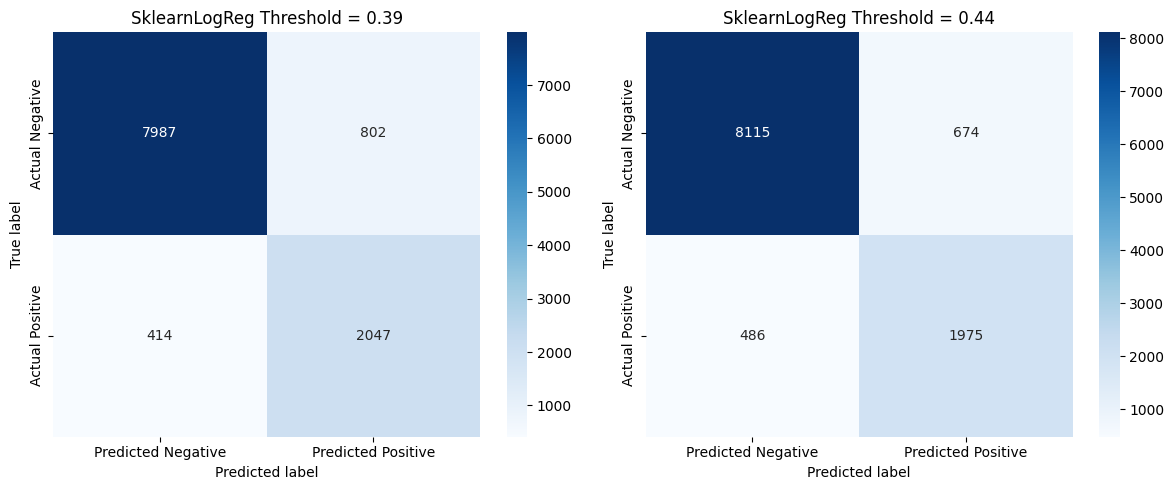

In [206]:
thresholds = [0.39, 0.44]

plot_confusion_matrix(y_test, my_proba, thresholds=thresholds, label='MyLogReg')

plot_confusion_matrix(y_test, sk_proba, thresholds=thresholds, label='SklearnLogReg')

# Интегральные модели

### Разделение на группы

In [140]:
# Классификация признаков
client_features = [
    "person_age", "person_gender", "person_education", 
    "person_income", "person_emp_exp", "person_home_ownership"
]

product_features = [
    "loan_amnt", "loan_intent", "loan_int_rate", "loan_percent_income"
]

credit_history_features = [
    "cb_person_cred_hist_length", "credit_score", "previous_loan_defaults_on_file"
]

all_features = client_features + product_features + credit_history_features


### Общая функция обучения и предсказания

In [141]:
def build_model(X_train, y_train, X_test, y_test):
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ])

    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:, 1]
    return clf, proba


### Тренировка моделей по группам

In [142]:
X_train = train.drop(TARGET, axis=1)
y_train = train[TARGET].values

X_test = test.drop(TARGET, axis=1)
y_test = test[TARGET].values


In [148]:
# По группам
models = {}
preds = {}
for group_name, features in {
    "client": client_features,
    "product": product_features,
    "credit": credit_history_features
}.items():
    X_tr, X_te = X_train[features], X_test[features]
    model, proba = build_model(X_tr, y_train, X_te, y_test)
    models[group_name] = model
    preds[group_name] = proba
    print(f"{group_name.title()} model ROC AUC: {roc_auc_score(y_test, proba):.3f}")


Client model ROC AUC: 0.743
Product model ROC AUC: 0.850
Credit model ROC AUC: 0.862


### Метамодель

In [149]:
# Используем предсказания как признаки
meta_X_train = pd.DataFrame({k: preds[k] for k in preds})
meta_model = LogisticRegression()
meta_model.fit(meta_X_train, y_test)

# Предсказания метамодели
meta_proba = meta_model.predict_proba(meta_X_train)[:, 1]
print(f"Meta-model ROC AUC: {roc_auc_score(y_test, meta_proba):.3f}")


Meta-model ROC AUC: 0.948


In [ ]:
## Модель на всех признаках
full_model, full_proba = build_model(X_train, y_train, X_test, y_test)
print(f"Full model ROC AUC: {roc_auc_score(y_test, full_proba):.3f}")


Full model ROC AUC: 0.957


### Сравнение моделей

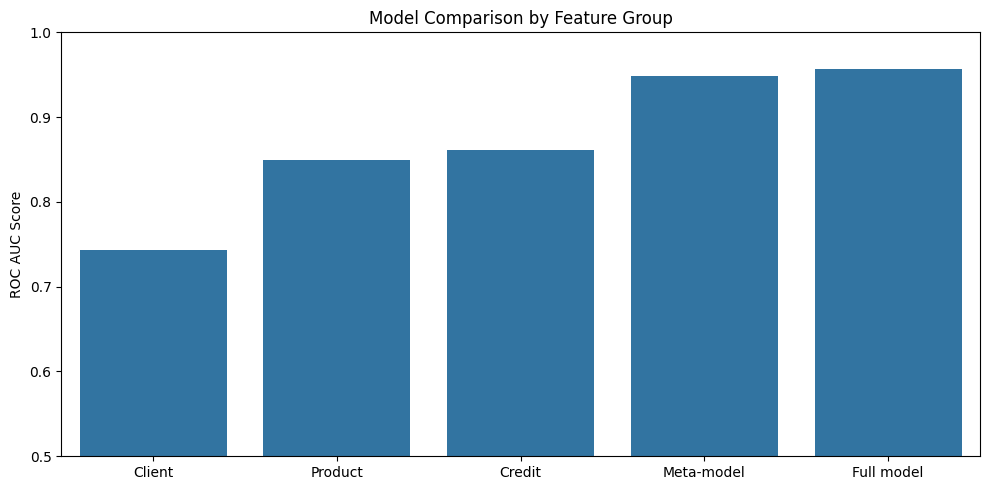

In [151]:
# Сравним ROC AUC
scores = {
    'Client': roc_auc_score(y_test, preds['client']),
    'Product': roc_auc_score(y_test, preds['product']),
    'Credit': roc_auc_score(y_test, preds['credit']),
    'Meta-model': roc_auc_score(y_test, meta_proba),
    'Full model': roc_auc_score(y_test, full_proba)
}

plt.figure(figsize=(10, 5))
sns.barplot(x=list(scores.keys()), y=list(scores.values()))
plt.ylabel('ROC AUC Score')
plt.title('Model Comparison by Feature Group')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


## Оценка зависимости качества модели от объема обучающихся данных

In [154]:
X_train = train.drop(TARGET, axis=1)
y_train = train[TARGET].values

X_test = test.drop(TARGET, axis=1)
y_test = test[TARGET].values

numeric_features = train.drop(TARGET, axis=1).select_dtypes(include=['int64', 'float64']).columns
categorical_features = train.drop(TARGET, axis=1).select_dtypes(include=['object', 'category']).columns


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


sample_sizes = [100, 500, 1000, 5000, 10000, len(X_train)]
roc_aucs = []

for size in sample_sizes:
    X_train_sample = X_train[:size]
    y_train_sample = y_train[:size]

    model = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', MyLogisticRegression())
    ])

    model.fit(X_train_sample, y_train_sample)
    y_test_proba = model.predict_proba(X_test)
    score = roc_auc_score(y_test, y_test_proba)
    roc_aucs.append(score)

    print(f"Train size: {size} → ROC AUC: {score:.3f}")


0 logloss: 4.788883316729091
50 logloss: 3.96262926117936
100 logloss: 3.2393773360054583
150 logloss: 2.614656389982207
200 logloss: 2.080865837438403
250 logloss: 1.6344303239017735
300 logloss: 1.2731282514095839
350 logloss: 0.9903241345903505
400 logloss: 0.7752645480941389
450 logloss: 0.616841347881127
500 logloss: 0.5044741014888673
550 logloss: 0.4273445128110421
600 logloss: 0.3748434340553328
650 logloss: 0.33839901650362486
700 logloss: 0.3122507009834038
750 logloss: 0.2928262251105005
800 logloss: 0.2779285700723688
850 logloss: 0.26616182427564977
900 logloss: 0.2566193395504121
950 logloss: 0.24869151982661777
Train size: 100 → ROC AUC: 0.849
0 logloss: 4.540679396200281
50 logloss: 1.7308904270803227
100 logloss: 0.6399845355932771
150 logloss: 0.38702629295066693
200 logloss: 0.34005041346880477
250 logloss: 0.32059179028027107
300 logloss: 0.30818611264905915
350 logloss: 0.29903668205808354
400 logloss: 0.291861364726916
450 logloss: 0.2860302475402066
500 logloss: 

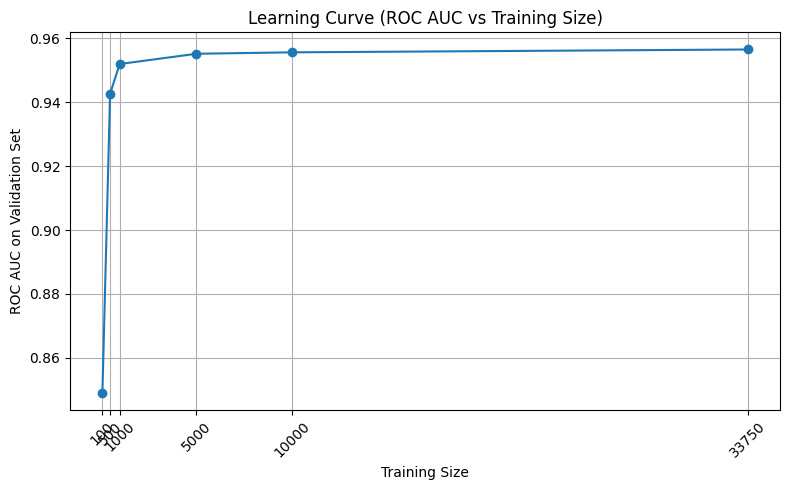

In [155]:
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, roc_aucs, marker='o')
plt.title("Learning Curve (ROC AUC vs Training Size)")
plt.xlabel("Training Size")
plt.ylabel("ROC AUC on Validation Set")
plt.grid(True)
plt.xticks(sample_sizes, rotation=45)
plt.tight_layout()
plt.show()
